# Penguins of Kyoto - Social Network Analysis

## Processing

In [84]:
#Preprocessing del dataset 
import pandas as pd
from pathlib import Path
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
import numpy as np
import os

In [85]:
# Folder where GEXF files are stored
DATA_DIR = "data/gexf"

# List of GEXF network files
gexf_files = [
    "Penguin_Complicated.gexf",
    "Penguin_Couples.gexf",
    "Penguin_Enemies.gexf",
    "Penguin_Exes.gexf",
    "Penguin_Family.gexf",
    "Penguin_Friends.gexf",
]

# Color assigned to each relationship type
color_map = {
    "Couples": "red",
    "Exes": "blue",
    "Complicated": "purple",
    "Family": "orange",
    "Friends": "green",
    "Enemies": "gray"
}

# Load metadata (gender, name, etc.)
metadata_path = "data/csv/Penguins of Kyoto - Metadata.csv"
meta = pd.read_csv(metadata_path)

# Clean Name field
meta["Name"] = meta["Name"].astype(str).str.strip()

# Map node → color based on gender
gender_map = {}
for _, row in meta.iterrows():
    name = str(row["Name"]).strip()
    gender = str(row["Gender"]).strip().lower()

    if gender.startswith("m"):
        gender_map[name] = "skyblue"      # male
    elif gender.startswith("f"):
        gender_map[name] = "lightpink"    # female
    else:
        gender_map[name] = "gray"         # unknown gender


In [86]:
# Final multigraph (multiple relations can exist between the same pair)
G = nx.MultiDiGraph()

# Load each GEXF file and merge it into the final graph
for file in gexf_files:
    path = os.path.join(DATA_DIR, file)
    relation = file.split("_")[1].split(".")[0]  # extract relation type

    print(f"→ Loading {relation} network...")
    G_read = nx.read_gexf(path)

    # Add edges and store their relation type
    for u, v in G_read.edges():
        G.add_edge(u, v, relationship_type=relation)

# Clean node names (remove trailing spaces)
mapping = {node: node.strip() for node in G.nodes()}
G = nx.relabel_nodes(G, mapping)

print(f"\nFinal network: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")


→ Loading Complicated network...
→ Loading Couples network...
→ Loading Enemies network...
→ Loading Exes network...
→ Loading Family network...
→ Loading Friends network...

Final network: 59 nodes, 139 edges


In [87]:
# Assegno il gender al grafo
gender_attr_map = dict(zip(meta["Name"], meta["Gender"]))
nx.set_node_attributes(G, gender_attr_map, name="gender")

# Verifica che tutti i nodi abbiano il genere
missing = [n for n in G.nodes() if G.nodes[n].get("gender") is None]
print("\nNodi senza genere:", missing)


Nodi senza genere: []


## Structure

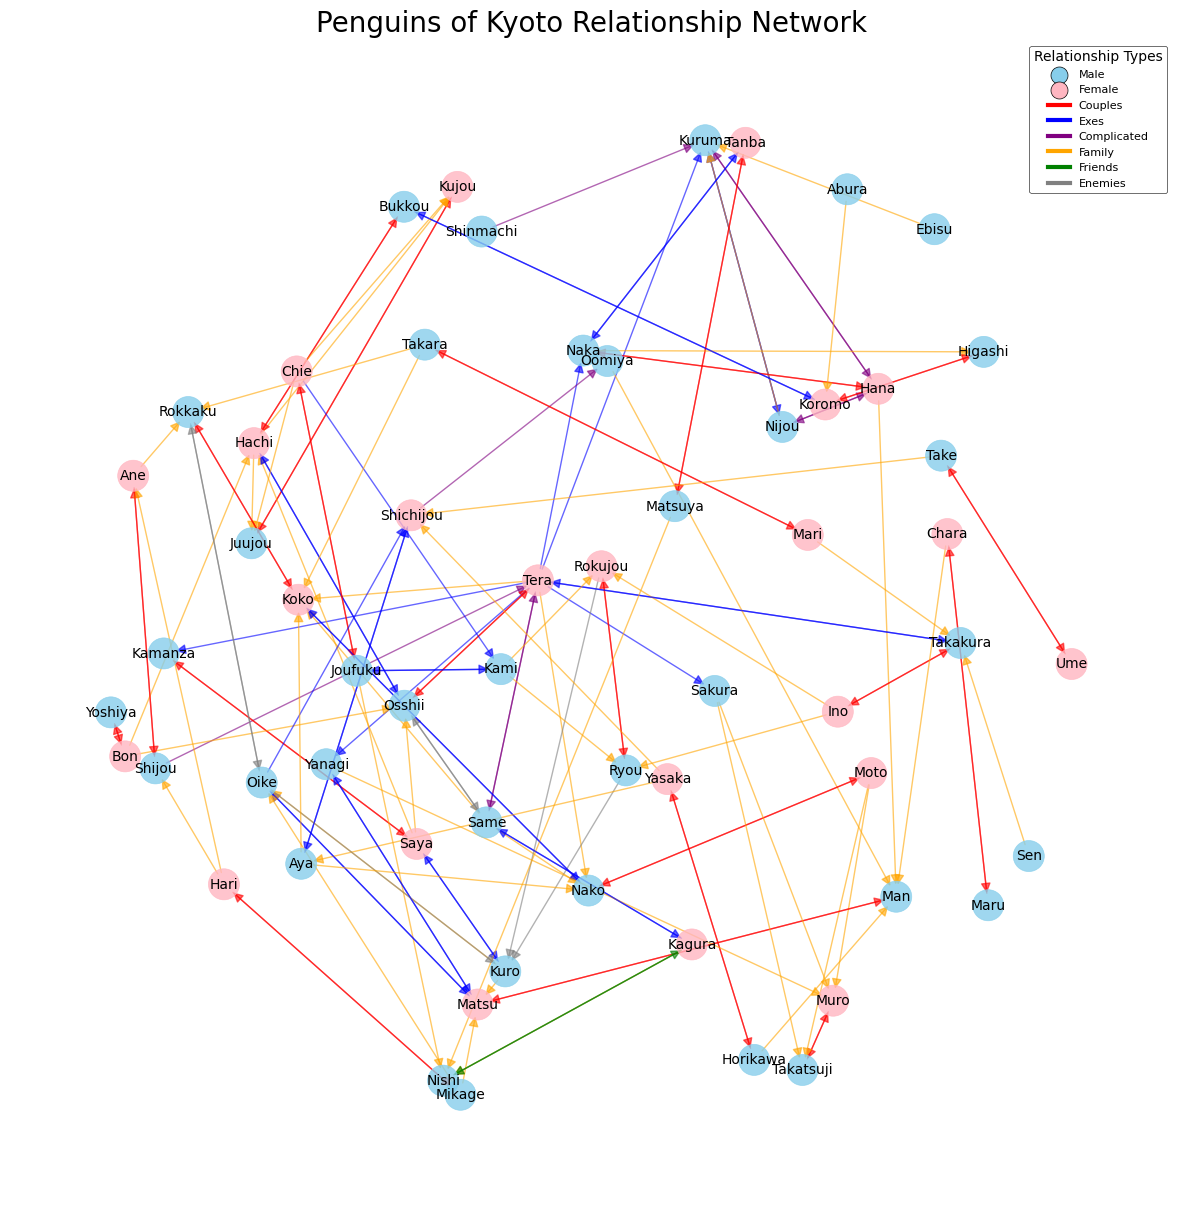

In [88]:
# Compute node positions (force-directed layout)
pos = nx.spring_layout(G, seed=42, k=0.8)

# Edge colors based on relationship type
edge_colors = [
    color_map[G[u][v][k]['relationship_type']]
    for u, v, k in G.edges(keys=True)
]

# Node colors based on gender
node_colors = [gender_map.get(node, "gray") for node in G.nodes()]

plt.figure(figsize=(15, 15))

# Draw nodes
nx.draw_networkx_nodes(
    G, pos,
    node_color=node_colors,
    node_size=500,
    alpha=0.8
)

# Draw directed edges
nx.draw_networkx_edges(
    G, pos,
    edge_color=edge_colors,
    arrows=True,
    arrowstyle='-|>',
    arrowsize=15,
    alpha=0.6
)

# Draw node labels
nx.draw_networkx_labels(G, pos, font_size=10, font_color='black')

plt.title("Penguins of Kyoto Relationship Network", fontsize=20)
plt.axis('off')

# Legend: gender
plt.scatter([], [], c="skyblue", label="Male", s=150, edgecolors="black")
plt.scatter([], [], c="lightpink", label="Female", s=150, edgecolors="black")

# Legend: relation types
for label, color in color_map.items():
    plt.plot([], [], color=color, label=label, linewidth=3)

plt.legend(
    title="Relationship Types",
    loc="upper right",
    fontsize=8,
    title_fontsize=10,
    frameon=True,
    facecolor="white",
    edgecolor="black"
)

plt.show()


In [89]:
# List all nodes
G.nodes

# List all edges
G.edges

# Basic graph size
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

# Check if graph is directed
is_direct_result = G.is_directed()
print("Graph is directed:", is_direct_result)

# Check if graph is bipartite
is_bipartite_result = nx.is_bipartite(G)
print("Graph is bipartite:", is_bipartite_result)

# Check if graph is unweighted
is_unweighted_result = all('weight' not in data for _, _, data in G.edges(data=True))
print("Graph is unweighted:", is_unweighted_result)

# Compute weakly connected components
components = list(nx.weakly_connected_components(G))
print("Number of connected components:", len(components))

# Convert to undirected version
G_und = G.to_undirected()

# Compute average shortest path length
average_path_length = nx.average_shortest_path_length(G_und)

# Compute graph diameter
diameter = nx.diameter(G_und)

print(f"Average path length (undirected): {average_path_length:.2f}")
print(f"Diameter (undirected): {diameter}")


Number of nodes: 59
Number of edges: 139
Graph is directed: True
Graph is bipartite: False
Graph is unweighted: True
Number of connected components: 1
Average path length (undirected): 3.75
Diameter (undirected): 9


In [90]:
# Compute degree of each node (number of connections)
degree_dict = dict(G.degree())

# Sort nodes by degree (highest → lowest)
sorted_degrees = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)

# Print ranked nodes by degree
print("Nodes sorted by degree (highest to lowest):")
for node, degree in sorted_degrees:
    print(f"Node: {node}, Degree: {degree}")

# Compute average degree
average_degree = sum(degree_dict.values()) / G.number_of_nodes()
print(f"Average degree of the network: {average_degree:.2f}")


Nodes sorted by degree (highest to lowest):
Node: Tera, Degree: 14
Node: Kuruma, Degree: 8
Node: Same, Degree: 8
Node: Osshii, Degree: 8
Node: Hachi, Degree: 8
Node: Matsu, Degree: 8
Node: Koko, Degree: 8
Node: Oike, Degree: 8
Node: Hana, Degree: 7
Node: Nako, Degree: 7
Node: Kuro, Degree: 7
Node: Shichijou, Degree: 6
Node: Saya, Degree: 6
Node: Takakura, Degree: 6
Node: Man, Degree: 6
Node: Rokkaku, Degree: 6
Node: Naka, Degree: 6
Node: Nijou, Degree: 5
Node: Muro, Degree: 5
Node: Ryou, Degree: 5
Node: Rokujou, Degree: 5
Node: Chie, Degree: 5
Node: Joufuku, Degree: 5
Node: Koromo, Degree: 5
Node: Kami, Degree: 5
Node: Kagura, Degree: 5
Node: Aya, Degree: 5
Node: Nishi, Degree: 5
Node: Shijou, Degree: 4
Node: Takatsuji, Degree: 4
Node: Juujou, Degree: 4
Node: Kujou, Degree: 4
Node: Moto, Degree: 4
Node: Bukkou, Degree: 4
Node: Ino, Degree: 4
Node: Tanba, Degree: 4
Node: Bon, Degree: 4
Node: Takara, Degree: 4
Node: Yasaka, Degree: 4
Node: Mikage, Degree: 4
Node: Hari, Degree: 4
Node: An

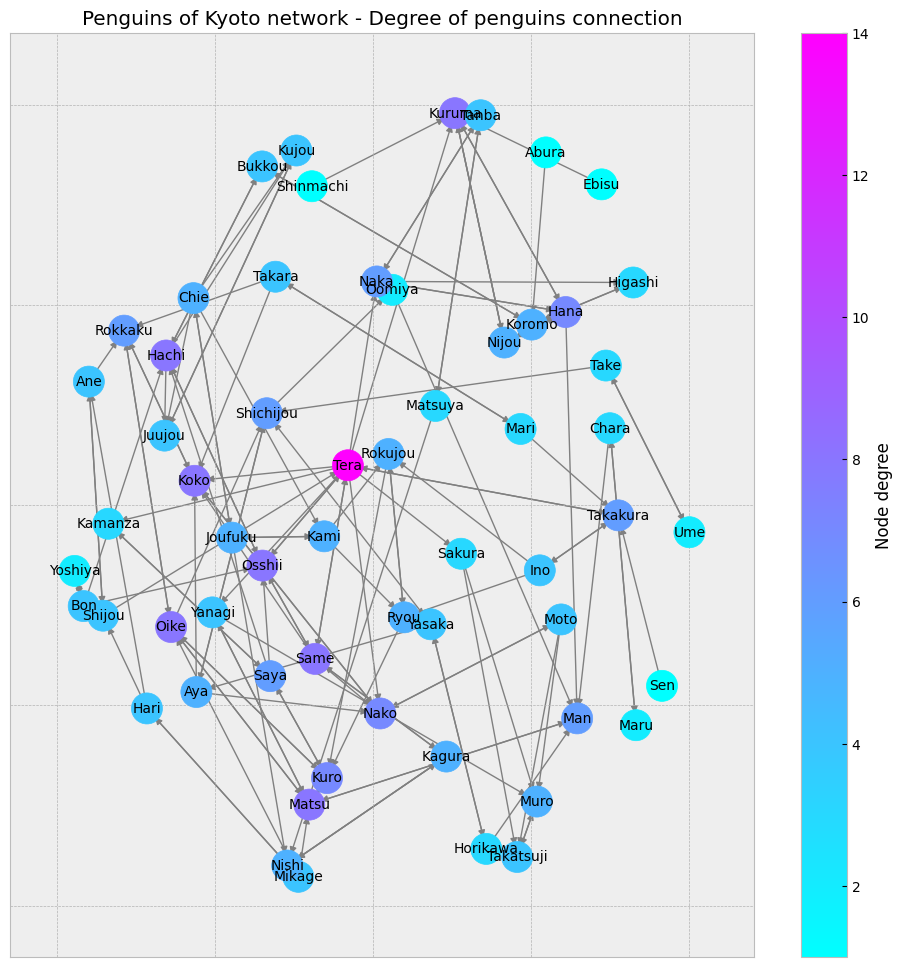

In [91]:
# Assign a color to each node based on its degree
colors = [degree_dict[node] for node in G.nodes()]

plt.figure(figsize=(12, 12))

# Compute node layout
pos = nx.spring_layout(G, seed=42, k=0.8)

# Draw nodes colored by degree
nodes = nx.draw_networkx_nodes(
    G, pos,
    node_size=500,
    node_color=colors,
    cmap=plt.cm.cool
)

# Draw edges
nx.draw_networkx_edges(G, pos, edge_color="gray")

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=10, font_color="black")

# Color bar
plt.colorbar(nodes, label='Node degree')

plt.title("Penguins of Kyoto network - Degree of penguins connection")
plt.show()


Top 6 nodes by indegree:
Node: Kuruma, Indegree: 6
Node: Koko, Indegree: 6
Node: Nako, Indegree: 5
Node: Osshii, Indegree: 5
Node: Matsu, Indegree: 5
Node: Man, Indegree: 5
Top 6 nodes by outdegree:
Node: Tera, Outdegree: 10
Node: Same, Outdegree: 5
Node: Hana, Outdegree: 4
Node: Saya, Outdegree: 4
Node: Hachi, Outdegree: 4
Node: Chie, Outdegree: 4


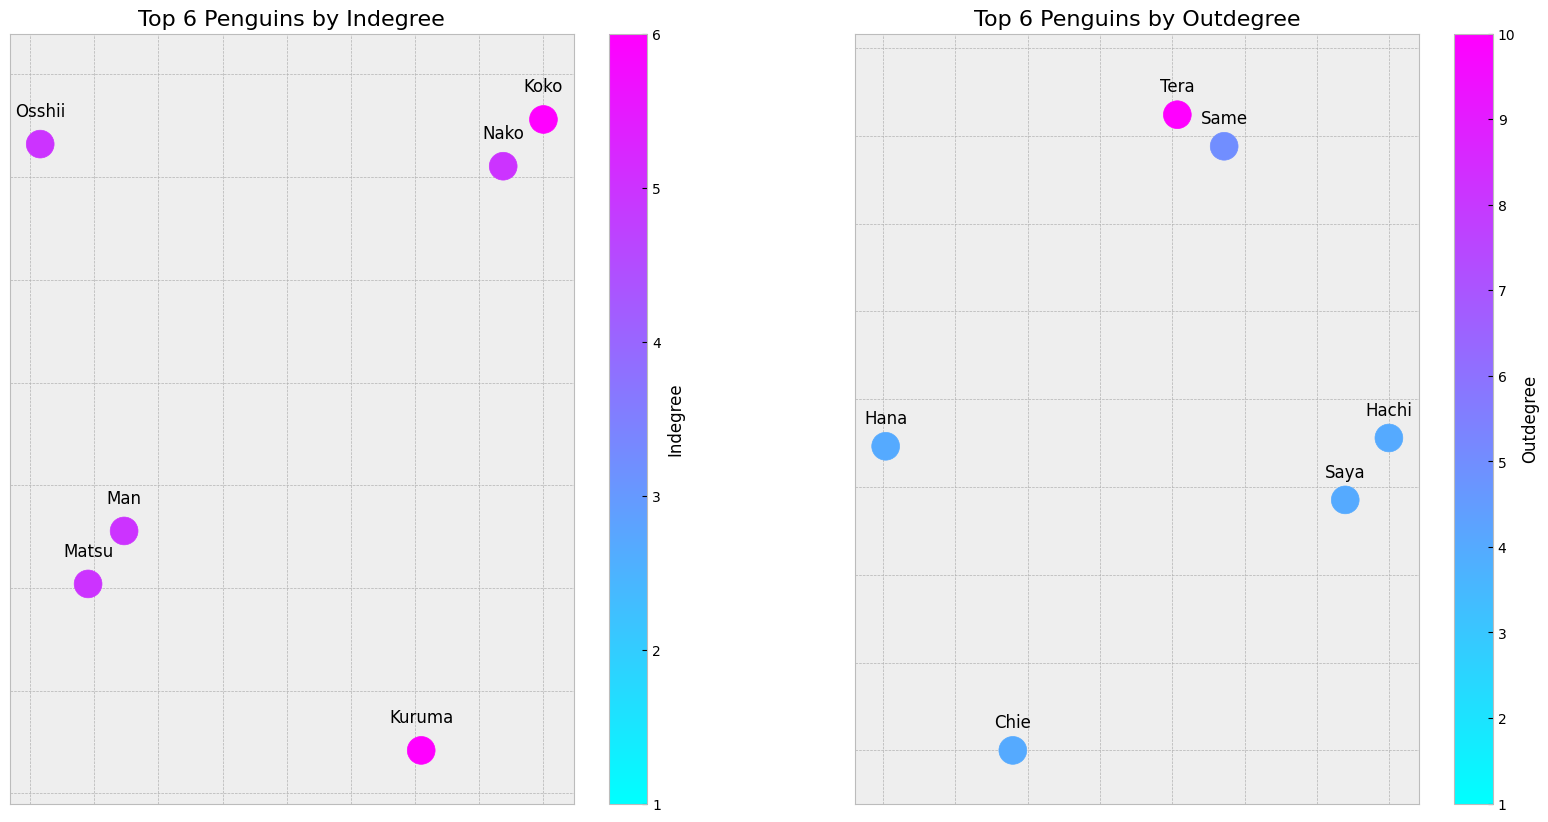

In [92]:
# Compute indegree and outdegree for each node
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())

# Top 6 nodes by indegree
top_in_degrees = sorted(in_degrees.items(), key=lambda x: x[1], reverse=True)[:6]
print("Top 6 nodes by indegree:")
for node, indeg in top_in_degrees:
    print(f"Node: {node}, Indegree: {indeg}")

# Top 6 nodes by outdegree
top_out_degrees = sorted(out_degrees.items(), key=lambda x: x[1], reverse=True)[:6]
print("Top 6 nodes by outdegree:")
for node, outdeg in top_out_degrees:
    print(f"Node: {node}, Outdegree: {outdeg}")

# --- Plot top 6 indegree and outdegree ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# ---------- INDEGREE ----------
top_in_nodes = [node for node, _ in top_in_degrees]
subgraph_in = G.subgraph(top_in_nodes)
pos_in = nx.spring_layout(subgraph_in)

# Global color range for indegree
global_in_min = min(in_degrees.values()) if in_degrees else 0
global_in_max = max(in_degrees.values()) if in_degrees else 1
vmin_in = 1 if global_in_min < 1 else global_in_min

# Draw nodes
nodes_in = nx.draw_networkx_nodes(
    subgraph_in, pos_in,
    node_size=400,
    node_color=[in_degrees[node] for node in subgraph_in.nodes()],
    cmap=plt.cm.cool,
    vmin=vmin_in, vmax=global_in_max,
    ax=ax1
)

# Move labels slightly up
label_offset_sub = 0.08
pos_in_labels = {n: (pos_in[n][0], pos_in[n][1] + label_offset_sub) for n in subgraph_in.nodes()}

# Draw labels only
nx.draw_networkx_labels(subgraph_in, pos_in_labels, font_size=12, font_color="black", ax=ax1)

ax1.set_title("Top 6 Penguins by Indegree", fontsize=16)

# ---------- OUTDEGREE ----------
top_out_nodes = [node for node, _ in top_out_degrees]
subgraph_out = G.subgraph(top_out_nodes)
pos_out = nx.spring_layout(subgraph_out)

# Global color range for outdegree
global_out_min = min(out_degrees.values()) if out_degrees else 0
global_out_max = max(out_degrees.values()) if out_degrees else 1
vmin_out = 1 if global_out_min < 1 else global_out_min

# Draw nodes
nodes_out = nx.draw_networkx_nodes(
    subgraph_out, pos_out,
    node_size=400,
    node_color=[out_degrees[node] for node in subgraph_out.nodes()],
    cmap=plt.cm.cool,
    vmin=vmin_out, vmax=global_out_max,
    ax=ax2
)

# Label offset
pos_out_labels = {n: (pos_out[n][0], pos_out[n][1] + label_offset_sub) for n in subgraph_out.nodes()}

# Draw labels only
nx.draw_networkx_labels(subgraph_out, pos_out_labels, font_size=12, font_color="black", ax=ax2)

ax2.set_title("Top 6 Penguins by Outdegree", fontsize=16)

# Colorbars
fig.colorbar(nodes_in, ax=ax1, label='Indegree')
fig.colorbar(nodes_out, ax=ax2, label='Outdegree')

# ---------- Adjust axis limits to include labels ----------

# Indegree axis limits
xs_in = [p[0] for p in pos_in.values()]
ys_in = [p[1] for p in pos_in.values()]
lxs_in = [p[0] for p in pos_in_labels.values()]
lys_in = [p[1] for p in pos_in_labels.values()]
xmin_i, xmax_i = min(xs_in), max(xs_in)
ymin_i, ymax_i = min(ys_in), max(ys_in)
xmin_i_final = min(xmin_i, min(lxs_in))
xmax_i_final = max(xmax_i, max(lxs_in))
ymin_i_final = min(ymin_i, min(lys_in))
ymax_i_final = max(ymax_i, max(lys_in))
xpad_i = 0.06 * (xmax_i_final - xmin_i_final) if xmax_i_final > xmin_i_final else 0.06
ypad_i = 0.08 * (ymax_i_final - ymin_i_final) if ymax_i_final > ymin_i_final else 0.08
ax1.set_xlim(xmin_i_final - xpad_i, xmax_i_final + xpad_i)
ax1.set_ylim(ymin_i_final - ypad_i, ymax_i_final + ypad_i)

# Outdegree axis limits
xs_o = [p[0] for p in pos_out.values()]
ys_o = [p[1] for p in pos_out.values()]
lxs_o = [p[0] for p in pos_out_labels.values()]
lys_o = [p[1] for p in pos_out_labels.values()]
xmin_o, xmax_o = min(xs_o), max(xs_o)
ymin_o, ymax_o = min(ys_o), max(ys_o)
xmin_o_final = min(xmin_o, min(lxs_o))
xmax_o_final = max(xmax_o, max(lxs_o))
ymin_o_final = min(ymin_o, min(lys_o))
ymax_o_final = max(ymax_o, max(lys_o))
xpad_o = 0.06 * (xmax_o_final - xmin_o_final) if xmax_o_final > xmin_o_final else 0.06
ypad_o = 0.08 * (ymax_o_final - ymin_o_final) if ymax_o_final > ymin_o_final else 0.08
ax2.set_xlim(xmin_o_final - xpad_o, xmax_o_final + xpad_o)
ax2.set_ylim(ymin_o_final - ypad_o, ymax_o_final + ypad_o)

plt.show()


## Centrality

In [93]:
# Compute degree centrality for each node
degree_centrality = nx.degree_centrality(G)

# Sort nodes by centrality (highest → lowest)
sorted_degree_centrality = {
    k: v for k, v in sorted(degree_centrality.items(), key=lambda item: item[1], reverse=True)
}

# Print results
print("Degree centrality (highest to lowest):")
for node, centrality in sorted_degree_centrality.items():
    print(f"Node {node}: {centrality:.4f}")


Degree centrality (highest to lowest):
Node Tera: 0.2414
Node Kuruma: 0.1379
Node Same: 0.1379
Node Osshii: 0.1379
Node Hachi: 0.1379
Node Matsu: 0.1379
Node Koko: 0.1379
Node Oike: 0.1379
Node Hana: 0.1207
Node Nako: 0.1207
Node Kuro: 0.1207
Node Shichijou: 0.1034
Node Saya: 0.1034
Node Takakura: 0.1034
Node Man: 0.1034
Node Rokkaku: 0.1034
Node Naka: 0.1034
Node Nijou: 0.0862
Node Muro: 0.0862
Node Ryou: 0.0862
Node Rokujou: 0.0862
Node Chie: 0.0862
Node Joufuku: 0.0862
Node Koromo: 0.0862
Node Kami: 0.0862
Node Kagura: 0.0862
Node Aya: 0.0862
Node Nishi: 0.0862
Node Shijou: 0.0690
Node Takatsuji: 0.0690
Node Juujou: 0.0690
Node Kujou: 0.0690
Node Moto: 0.0690
Node Bukkou: 0.0690
Node Ino: 0.0690
Node Tanba: 0.0690
Node Bon: 0.0690
Node Takara: 0.0690
Node Yasaka: 0.0690
Node Mikage: 0.0690
Node Hari: 0.0690
Node Ane: 0.0690
Node Yanagi: 0.0690
Node Kamanza: 0.0517
Node Matsuya: 0.0517
Node Mari: 0.0517
Node Chara: 0.0517
Node Horikawa: 0.0517
Node Higashi: 0.0517
Node Take: 0.0517
N

In [94]:
# Compute betweenness centrality for each node
betweenness_centrality = nx.betweenness_centrality(G)

# Sort nodes by betweenness (highest → lowest)
sorted_betweenness_centrality = {
    k: v for k, v in sorted(betweenness_centrality.items(), key=lambda item: item[1], reverse=True)
}

# Print results
print("Betweenness centrality (highest to lowest):")
for node, centrality in sorted_betweenness_centrality.items():
    print(f"Node {node}: {centrality:.4f}")


Betweenness centrality (highest to lowest):
Node Tera: 0.2450
Node Oike: 0.2034
Node Osshii: 0.1959
Node Kuro: 0.1795
Node Saya: 0.1676
Node Matsu: 0.1313
Node Hachi: 0.0992
Node Man: 0.0947
Node Rokkaku: 0.0840
Node Same: 0.0819
Node Naka: 0.0808
Node Takakura: 0.0744
Node Koko: 0.0700
Node Shichijou: 0.0569
Node Bukkou: 0.0566
Node Hana: 0.0557
Node Kagura: 0.0537
Node Kuruma: 0.0448
Node Koromo: 0.0403
Node Nishi: 0.0338
Node Nako: 0.0322
Node Ino: 0.0311
Node Tanba: 0.0294
Node Aya: 0.0285
Node Yanagi: 0.0259
Node Shijou: 0.0223
Node Higashi: 0.0197
Node Oomiya: 0.0151
Node Matsuya: 0.0150
Node Bon: 0.0115
Node Chara: 0.0115
Node Take: 0.0115
Node Ryou: 0.0108
Node Rokujou: 0.0108
Node Kami: 0.0098
Node Sakura: 0.0094
Node Kamanza: 0.0090
Node Joufuku: 0.0090
Node Moto: 0.0068
Node Mari: 0.0065
Node Hari: 0.0061
Node Muro: 0.0058
Node Horikawa: 0.0048
Node Mikage: 0.0025
Node Takara: 0.0024
Node Yasaka: 0.0021
Node Ane: 0.0021
Node Chie: 0.0012
Node Nijou: 0.0000
Node Shinmachi: 0.

In [95]:
# Compute closeness centrality for each node
closeness_centrality = nx.closeness_centrality(G)

# Sort nodes by closeness (highest → lowest)
sorted_closeness = sorted(closeness_centrality.items(), key=lambda item: item[1], reverse=True)

# Print results
print("Closeness centrality (highest to lowest):")
for node, closeness in sorted_closeness:
    print(f"{node}: {closeness:.4f}")


Closeness centrality (highest to lowest):
Matsu: 0.2767
Koko: 0.2590
Yanagi: 0.2522
Man: 0.2509
Rokkaku: 0.2509
Oike: 0.2471
Muro: 0.2371
Nako: 0.2351
Kuro: 0.2211
Takatsuji: 0.2171
Shichijou: 0.2143
Osshii: 0.2143
Hachi: 0.2106
Saya: 0.2035
Kamanza: 0.1953
Same: 0.1945
Tera: 0.1914
Juujou: 0.1903
Kujou: 0.1903
Kuruma: 0.1892
Naka: 0.1884
Moto: 0.1877
Bukkou: 0.1856
Oomiya: 0.1761
Aya: 0.1755
Kagura: 0.1748
Koromo: 0.1705
Higashi: 0.1670
Sakura: 0.1638
Takakura: 0.1631
Hana: 0.1609
Nijou: 0.1593
Tanba: 0.1578
Nishi: 0.1578
Ino: 0.1388
Matsuya: 0.1349
Ryou: 0.1302
Rokujou: 0.1302
Shijou: 0.0388
Ane: 0.0388
Joufuku: 0.0345
Kami: 0.0345
Chie: 0.0230
Bon: 0.0172
Yoshiya: 0.0172
Takara: 0.0172
Mari: 0.0172
Chara: 0.0172
Maru: 0.0172
Horikawa: 0.0172
Yasaka: 0.0172
Mikage: 0.0172
Hari: 0.0172
Take: 0.0172
Ume: 0.0172
Shinmachi: 0.0000
Ebisu: 0.0000
Abura: 0.0000
Sen: 0.0000


In [96]:
# Compute load centrality for each node
load_centrality = nx.load_centrality(G)

# Sort nodes by load centrality (highest → lowest)
sorted_load_centrality = sorted(load_centrality.items(), key=lambda item: item[1], reverse=True)

# Print results
print("Load centrality (highest to lowest):")
for node, load in sorted_load_centrality:
    print(f"{node}: {load:.4f}")


Load centrality (highest to lowest):
Tera: 0.2468
Oike: 0.2025
Osshii: 0.1941
Kuro: 0.1770
Saya: 0.1659
Matsu: 0.1329
Hachi: 0.0984
Man: 0.0939
Same: 0.0837
Rokkaku: 0.0825
Naka: 0.0812
Takakura: 0.0747
Koko: 0.0687
Shichijou: 0.0569
Kagura: 0.0563
Bukkou: 0.0557
Hana: 0.0549
Kuruma: 0.0445
Koromo: 0.0395
Nishi: 0.0363
Nako: 0.0323
Tanba: 0.0309
Ino: 0.0307
Aya: 0.0285
Yanagi: 0.0282
Shijou: 0.0224
Higashi: 0.0190
Matsuya: 0.0165
Oomiya: 0.0151
Bon: 0.0115
Chara: 0.0115
Take: 0.0115
Ryou: 0.0100
Rokujou: 0.0100
Joufuku: 0.0097
Sakura: 0.0096
Kami: 0.0093
Kamanza: 0.0091
Moto: 0.0069
Mari: 0.0065
Hari: 0.0061
Muro: 0.0058
Horikawa: 0.0048
Mikage: 0.0025
Takara: 0.0024
Yasaka: 0.0021
Ane: 0.0021
Chie: 0.0012
Nijou: 0.0000
Shinmachi: 0.0000
Takatsuji: 0.0000
Juujou: 0.0000
Kujou: 0.0000
Yoshiya: 0.0000
Maru: 0.0000
Ume: 0.0000
Ebisu: 0.0000
Abura: 0.0000
Sen: 0.0000


In [97]:
# Top 5 nodes by degree centrality
top_degree = sorted(degree_dict.items(), key=lambda item: item[1], reverse=True)[:5]
print("Top 5 nodes by degree:", top_degree)

# Top 5 nodes by betweenness centrality
top_betweenness = sorted(betweenness_centrality.items(), key=lambda item: item[1], reverse=True)[:5]
print("Top 5 nodes by betweenness:", top_betweenness)

# Top 5 nodes by closeness centrality
top_closeness = sorted(closeness_centrality.items(), key=lambda item: item[1], reverse=True)[:5]
print("Top 5 nodes by closeness:", top_closeness)

# Top 5 nodes by load centrality
top_load = sorted(load_centrality.items(), key=lambda item: item[1], reverse=True)[:5]
print("Top 5 nodes by load:", top_load)


Top 5 nodes by degree: [('Tera', 14), ('Kuruma', 8), ('Same', 8), ('Osshii', 8), ('Hachi', 8)]
Top 5 nodes by betweenness: [('Tera', 0.24503428110506148), ('Oike', 0.20339282113329302), ('Osshii', 0.19585097801976206), ('Kuro', 0.17948175035289374), ('Saya', 0.16756402500504136)]
Top 5 nodes by closeness: [('Matsu', 0.2767487684729064), ('Koko', 0.258989489212613), ('Yanagi', 0.25224497126436785), ('Man', 0.25093800250134), ('Rokkaku', 0.25093800250134)]
Top 5 nodes by load: [('Tera', 0.2467735430530349), ('Oike', 0.20248538011695907), ('Osshii', 0.1941167574107683), ('Kuro', 0.17700141157491434), ('Saya', 0.16591046581972174)]


In [98]:
# ---- Eigenvector centrality (UNDIRECTED) ----

# Convert MultiDiGraph → simple undirected graph
G_simple = nx.Graph(G)

# Compute eigenvector centrality
eigen_centrality = nx.eigenvector_centrality(G_simple, max_iter=1000)

# Sort results (highest → lowest)
sorted_eigen = sorted(eigen_centrality.items(), key=lambda x: x[1], reverse=True)

print("\nEigenvector Centrality (UNDIRECTED) (top → bottom):")
for node, value in sorted_eigen:
    print(f"{node}: {value:.4f}")


# ---- Eigenvector centrality (DIRECTED) ----

# Convert MultiDiGraph → directed simple graph
G_directed = nx.DiGraph(G)

# Compute directed eigenvector centrality
eigen_directed = nx.eigenvector_centrality(G_directed, max_iter=2000)

# Sort results (highest → lowest)
sorted_eigen_directed = sorted(eigen_directed.items(), key=lambda x: x[1], reverse=True)

print("\nEigenvector Centrality (DIRECTED) (top → bottom):")
for node, value in sorted_eigen_directed:
    print(f"{node}: {value:.4f}")



Eigenvector Centrality (UNDIRECTED) (top → bottom):
Tera: 0.4869
Koko: 0.3393
Same: 0.3212
Nako: 0.3130
Osshii: 0.2545
Aya: 0.1753
Yanagi: 0.1523
Kuruma: 0.1516
Sakura: 0.1471
Naka: 0.1404
Rokkaku: 0.1387
Takakura: 0.1365
Kamanza: 0.1361
Saya: 0.1356
Shijou: 0.1350
Hachi: 0.1317
Takara: 0.1166
Moto: 0.1091
Muro: 0.1067
Oike: 0.1060
Matsu: 0.1032
Kuro: 0.0979
Bon: 0.0887
Hana: 0.0878
Shichijou: 0.0865
Takatsuji: 0.0793
Kagura: 0.0753
Ane: 0.0726
Yasaka: 0.0630
Mikage: 0.0584
Hari: 0.0582
Man: 0.0572
Mari: 0.0553
Ino: 0.0524
Nijou: 0.0523
Ryou: 0.0515
Rokujou: 0.0515
Juujou: 0.0457
Kujou: 0.0457
Higashi: 0.0340
Kami: 0.0336
Tanba: 0.0334
Shinmachi: 0.0331
Ebisu: 0.0331
Bukkou: 0.0321
Chie: 0.0316
Oomiya: 0.0314
Sen: 0.0299
Horikawa: 0.0263
Nishi: 0.0234
Take: 0.0199
Yoshiya: 0.0194
Joufuku: 0.0194
Koromo: 0.0152
Chara: 0.0131
Matsuya: 0.0124
Ume: 0.0043
Abura: 0.0033
Maru: 0.0029

Eigenvector Centrality (DIRECTED) (top → bottom):
Koko: 0.3751
Nako: 0.3473
Matsu: 0.2825
Oike: 0.2448
Ossh

## Community

In [99]:
import networkx as nx
import pandas as pd
import numpy as np

# ---- Relationship weights (interaction strength) ----
RELATION_WEIGHTS = {
    "Friends": 1.0,
    "Couples": 1.0,
    "Complicated": 0.7,
    "Exes": 0.5,
    "Enemies": 0.0,
    "Family": 0.3
}

# ---- Convert MultiDiGraph → simple weighted undirected graph ----
weighted_graph = nx.Graph()

for u, v, data in G.edges(data=True):
    rel_type = data.get("relationship_type", "")
    weight = RELATION_WEIGHTS.get(rel_type, 0.1)

    if weighted_graph.has_edge(u, v):
        weighted_graph[u][v]["weight"] += weight  # accumulate weight
    else:
        weighted_graph.add_edge(u, v, weight=weight)

print(f"Weighted graph: {weighted_graph.number_of_nodes()} nodes, {weighted_graph.number_of_edges()} edges")

# ---- Weighted clustering and transitivity ----
local_clustering = nx.clustering(weighted_graph, weight='weight')
avg_clustering = nx.average_clustering(weighted_graph, weight='weight')
global_transitivity = nx.transitivity(weighted_graph)


# ---- Weighted cliquishness (neighbors only) ----
def weighted_cliquishness(G, node):
    neighbors = list(G.neighbors(node))
    if len(neighbors) < 2:
        return 0.0

    subgraph = G.subgraph(neighbors)  # neighbor-only subgraph

    # Weighted density
    possible_edges = len(neighbors)*(len(neighbors)-1)/2
    actual_weight = sum(d.get("weight", 1) for _, _, d in subgraph.edges(data=True))
    max_possible_weight = possible_edges * max(RELATION_WEIGHTS.values())
    density_score = actual_weight / max_possible_weight

    # Neighbor strength adjustment
    neighbor_strengths = [G.degree(n, weight="weight") for n in neighbors]
    strength_factor = np.mean(neighbor_strengths) / max(dict(G.degree(weight="weight")).values())

    return density_score * strength_factor


# ---- Extended cliquishness (ego-radius = 2) ----
def extended_ego_cliquishness(G, node):
    ego_graph = nx.ego_graph(G, node, radius=2)
    n_nodes = ego_graph.number_of_nodes()
    if n_nodes < 3:
        return 0.0

    possible_edges = n_nodes*(n_nodes-1)/2
    actual_weight = sum(d.get("weight", 1) for _, _, d in ego_graph.edges(data=True))
    max_possible_weight = possible_edges * max(RELATION_WEIGHTS.values())

    return actual_weight / max_possible_weight


# ---- Degree-normalized cliquishness ----
def degree_normalized_cliquishness(G, node):
    c = nx.clustering(G, node, weight="weight")
    k = G.degree(node, weight="weight")
    if k == 0:
        return 0.0
    return c / (1 + np.log1p(k))


# ---- Build dataframe of metrics ----
weighted_degrees = dict(weighted_graph.degree(weight="weight"))
degree_centrality = nx.degree_centrality(weighted_graph)

metrics_df = pd.DataFrame({
    "node": list(weighted_graph.nodes()),
    "weighted_degree": [weighted_degrees[n] for n in weighted_graph.nodes()],
    "degree_centrality": [degree_centrality[n] for n in weighted_graph.nodes()],
    "local_clustering": [local_clustering[n] for n in weighted_graph.nodes()],
    "weighted_cliquishness": [weighted_cliquishness(weighted_graph, n) for n in weighted_graph.nodes()],
    "extended_ego_cliquishness": [extended_ego_cliquishness(weighted_graph, n) for n in weighted_graph.nodes()],
    "degree_normalized_cliquishness": [degree_normalized_cliquishness(weighted_graph, n) for n in weighted_graph.nodes()]
}).set_index("node")

# Difference between cliquishness and clustering
metrics_df["cliquishness_vs_clustering_delta"] = (
    metrics_df["weighted_cliquishness"] - metrics_df["local_clustering"]
)

# ---- Global results ----
print(f"Average weighted clustering: {avg_clustering:.4f}")
print(f"Global transitivity: {global_transitivity:.4f}")
print(f"Mean weighted cliquishness: {metrics_df['weighted_cliquishness'].mean():.4f}")
print(f"Mean extended ego cliquishness: {metrics_df['extended_ego_cliquishness'].mean():.4f}")
print(f"Mean degree-normalized cliquishness: {metrics_df['degree_normalized_cliquishness'].mean():.4f}")

# ---- Node rankings ----
print("\nTop nodes by weighted cliquishness:")
print(metrics_df.sort_values("weighted_cliquishness", ascending=False))

print("\nTop nodes by extended ego cliquishness:")
print(metrics_df.sort_values("extended_ego_cliquishness", ascending=False))

# ---- Export results ----
output_file = "export/cliquishness_clustering_results.csv"
metrics_df.to_csv(output_file)
print(f"\nResults saved to: {output_file}")


Weighted graph: 59 nodes, 97 edges
Average weighted clustering: 0.0541
Global transitivity: 0.2171
Mean weighted cliquishness: 0.0740
Mean extended ego cliquishness: 0.2398
Mean degree-normalized cliquishness: 0.0233

Top nodes by weighted cliquishness:
           weighted_degree  degree_centrality  local_clustering  \
node                                                              
Nijou                  2.7           0.034483          0.593843   
Sakura                 1.1           0.051724          0.081829   
Moto                   2.6           0.051724          0.081829   
Takara                 2.6           0.051724          0.081829   
Ino                    2.6           0.051724          0.081829   
Kami                   2.1           0.068966          0.113378   
Hari                   2.6           0.051724          0.081829   
Same                   3.0           0.086207          0.063078   
Chie                   3.1           0.068966          0.113378   
Bon      

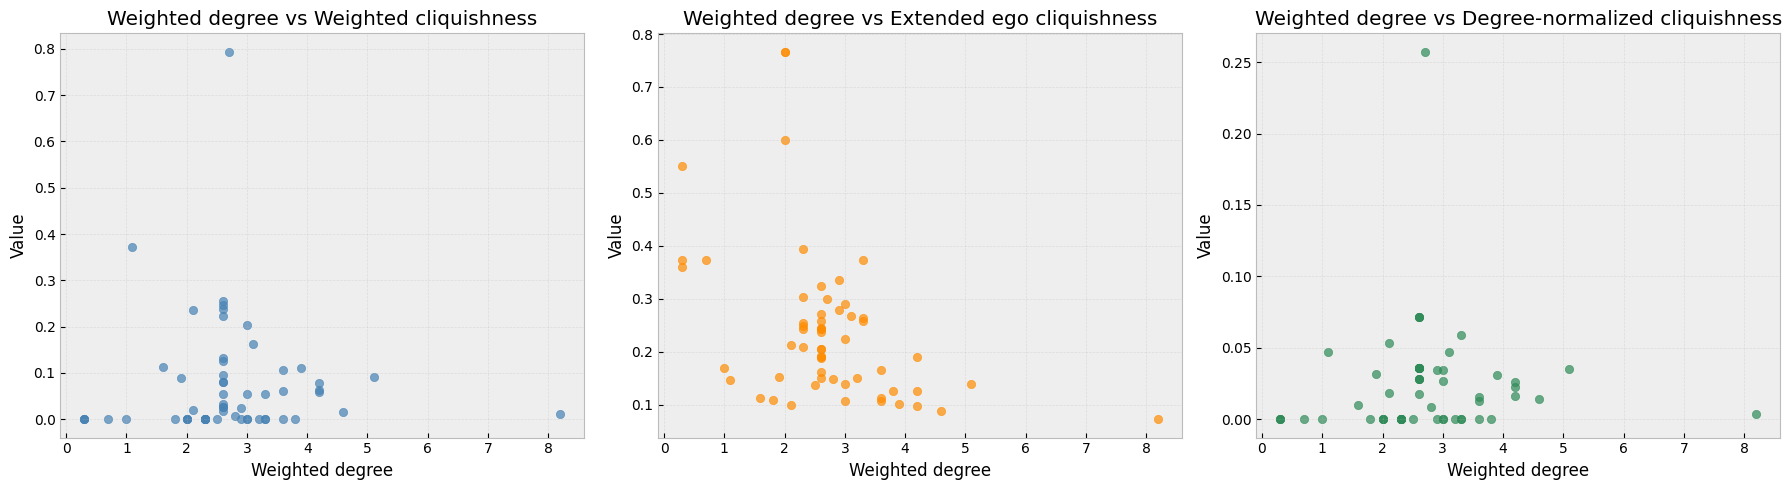

<Figure size 1000x600 with 0 Axes>

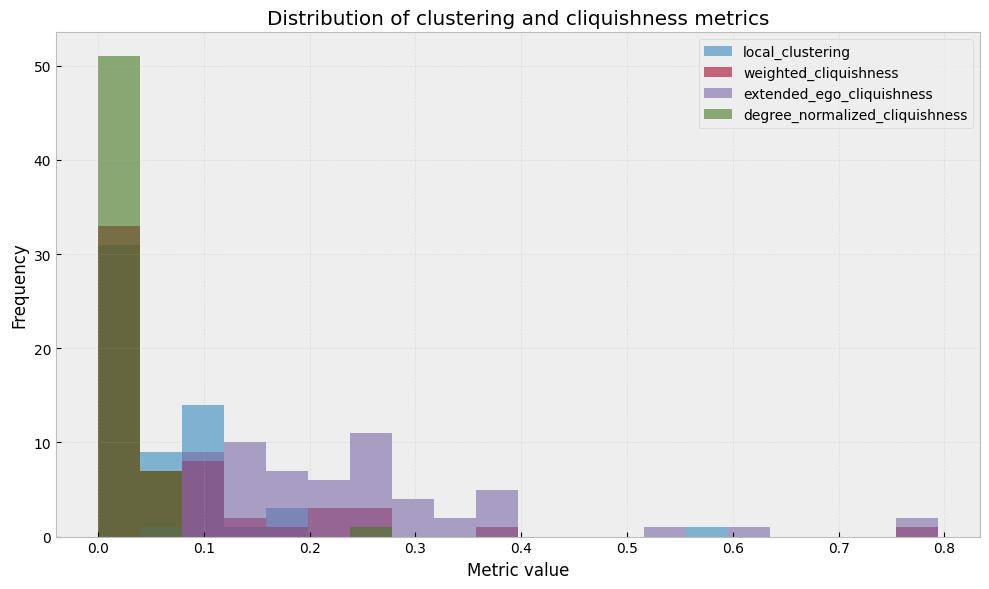

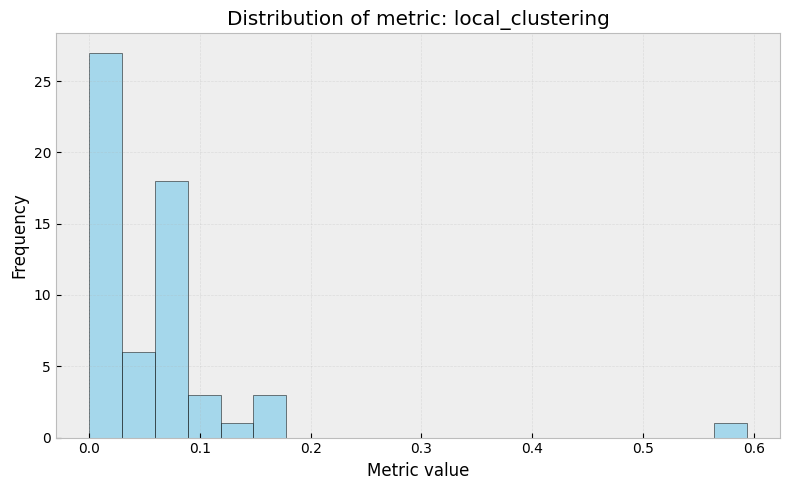

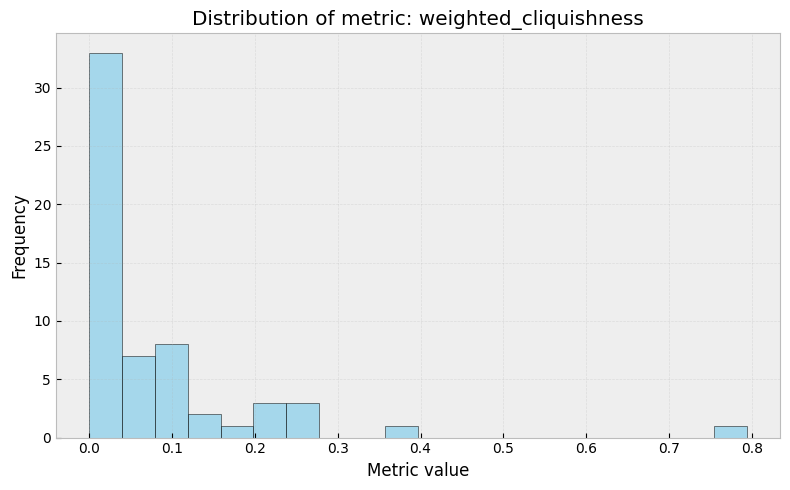

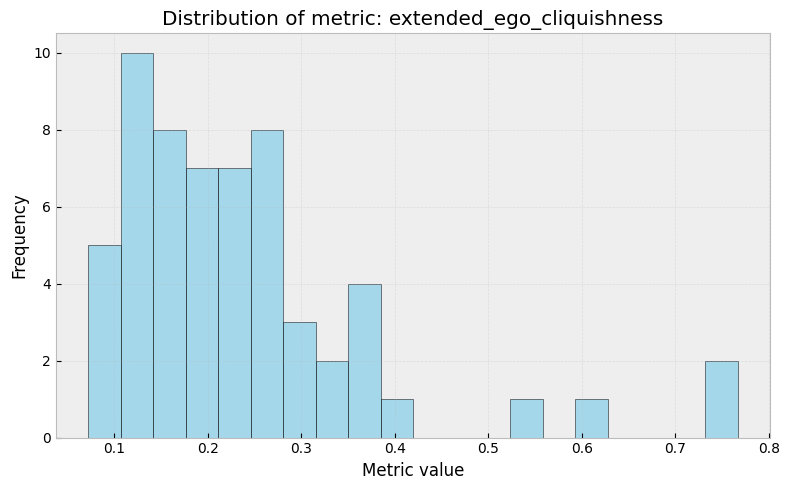

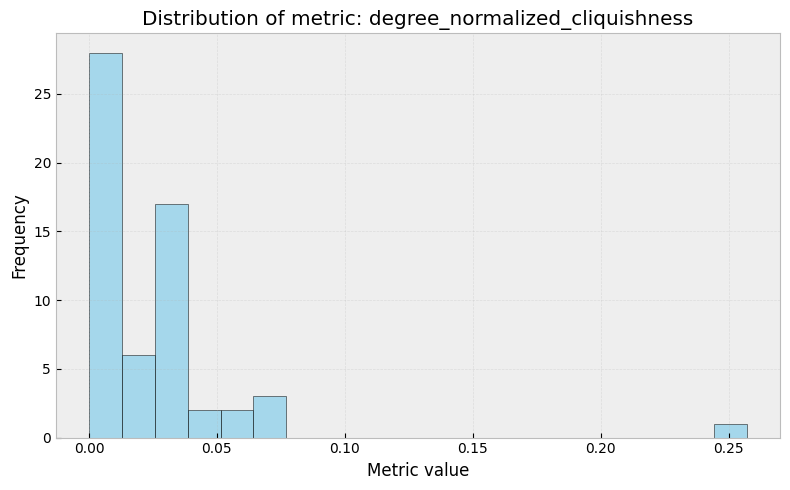

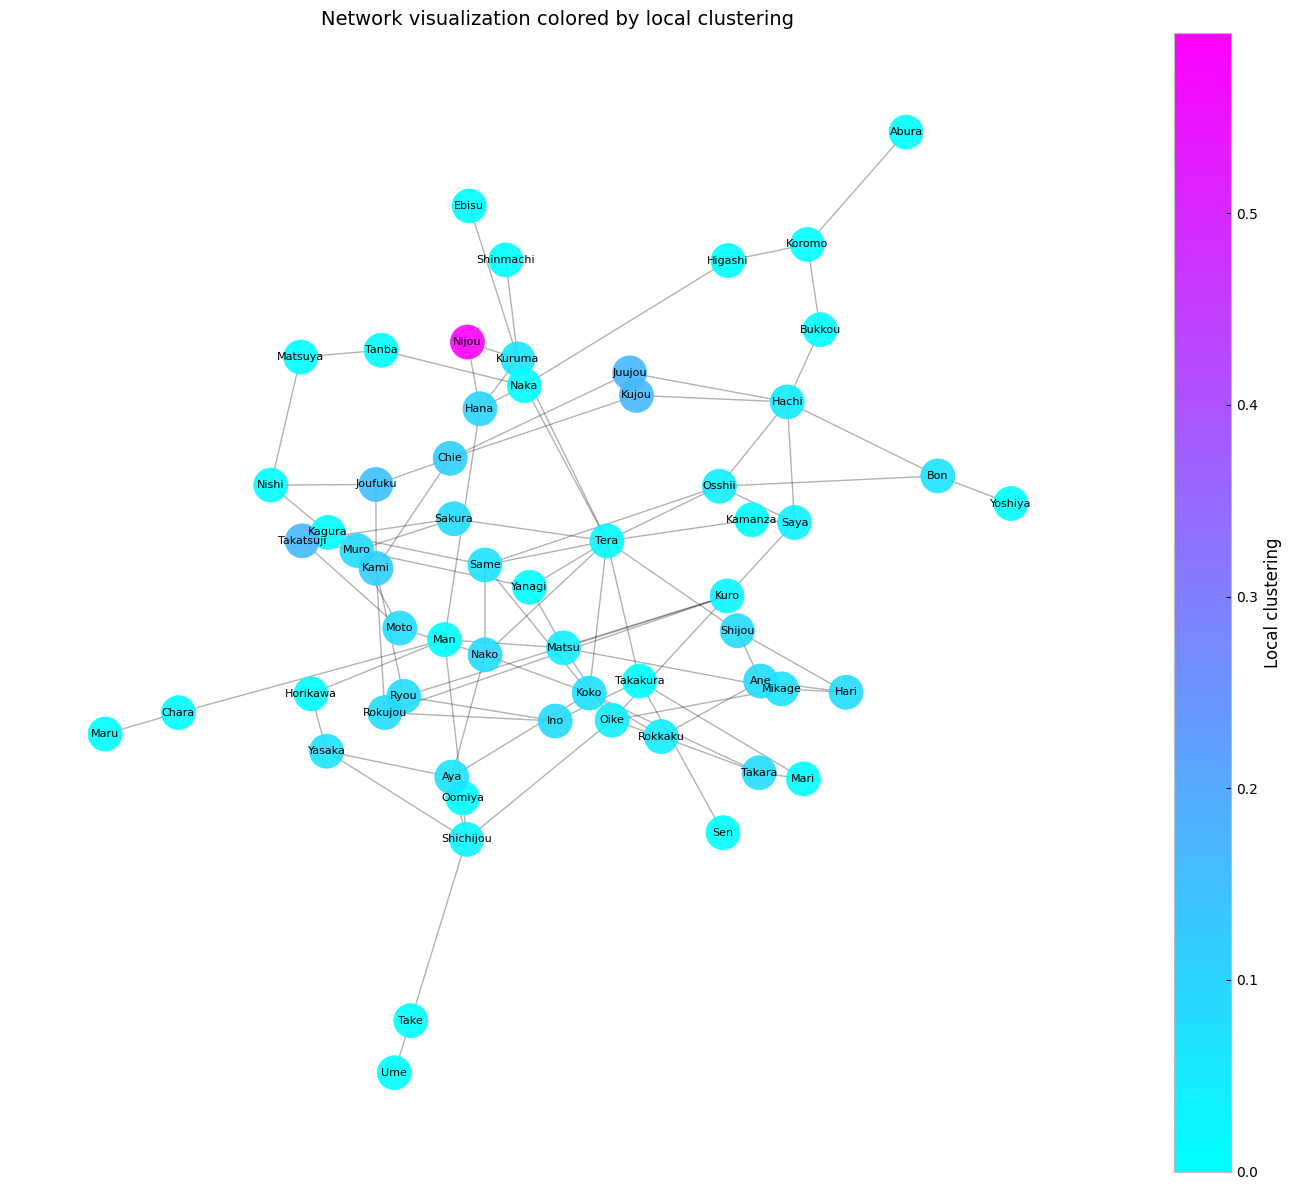

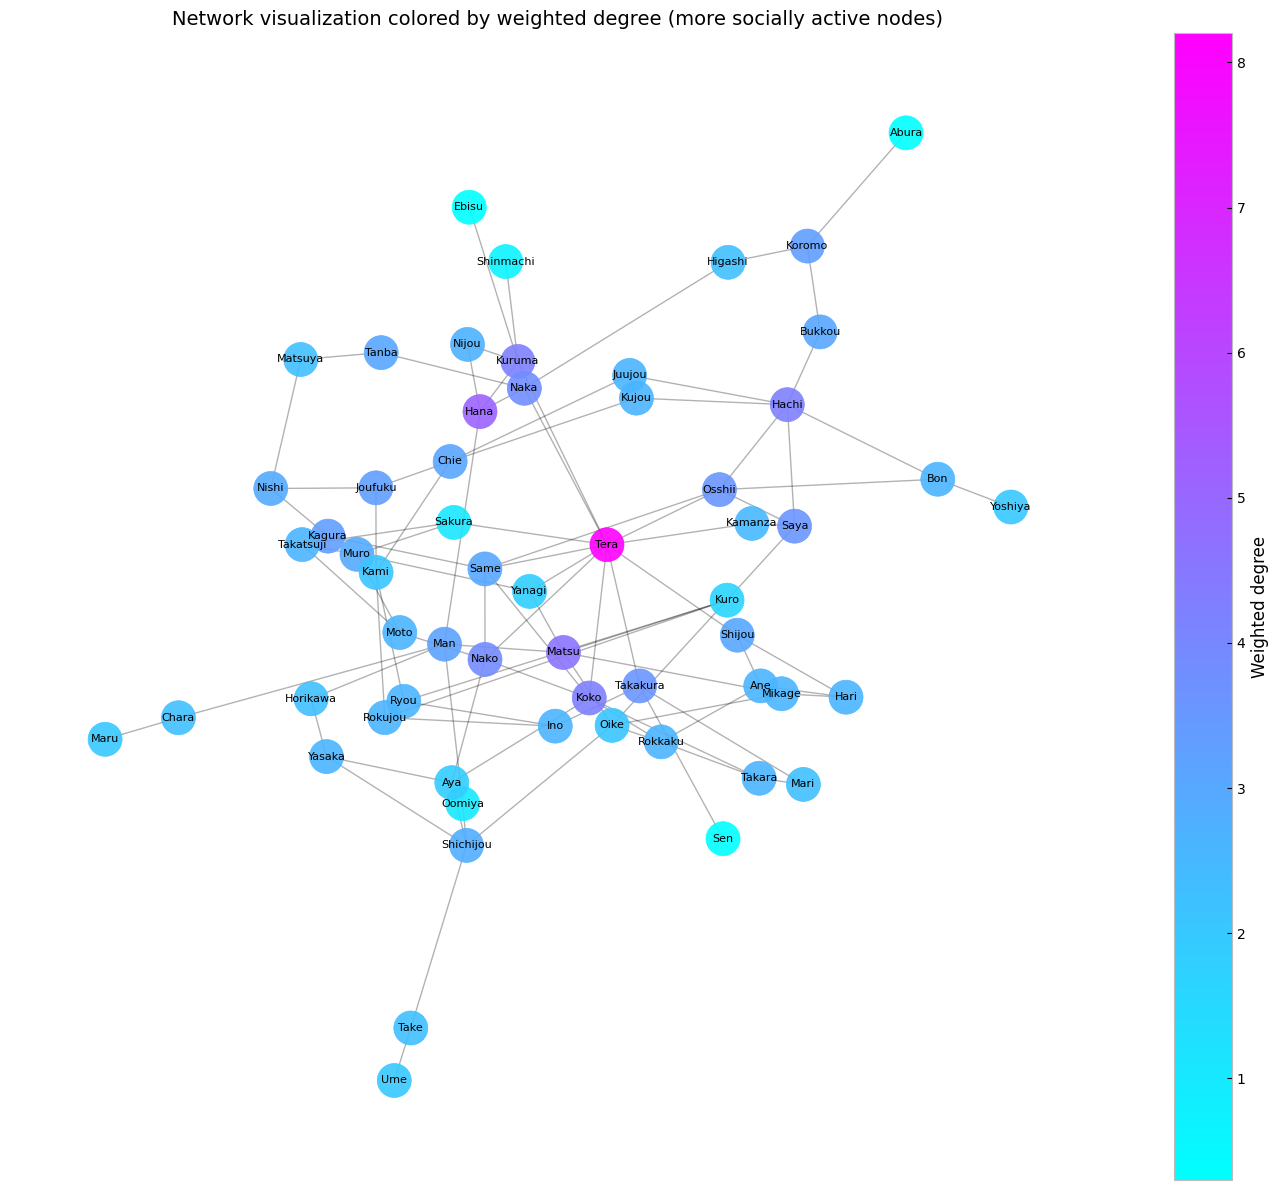

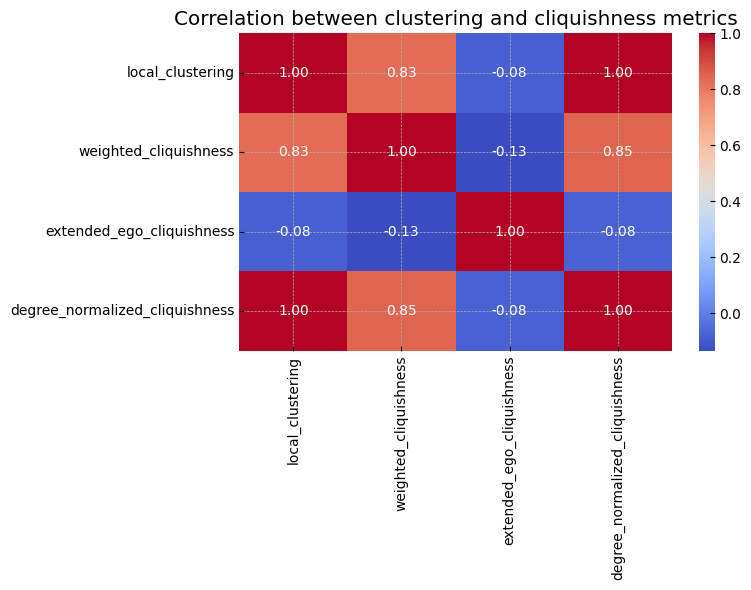

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- SCATTER PLOTS: weighted degree vs cliquishness metrics ---
fig, axes = plt.subplots(1, 3, figsize=(18,5))

axes[0].scatter(metrics_df["weighted_degree"], metrics_df["weighted_cliquishness"], alpha=0.7, color="steelblue")
axes[0].set_title("Weighted degree vs Weighted cliquishness")
axes[0].set_xlabel("Weighted degree")
axes[0].set_ylabel("Value")

axes[1].scatter(metrics_df["weighted_degree"], metrics_df["extended_ego_cliquishness"], alpha=0.7, color="darkorange")
axes[1].set_title("Weighted degree vs Extended ego cliquishness")
axes[1].set_xlabel("Weighted degree")
axes[1].set_ylabel("Value")

axes[2].scatter(metrics_df["weighted_degree"], metrics_df["degree_normalized_cliquishness"], alpha=0.7, color="seagreen")
axes[2].set_title("Weighted degree vs Degree-normalized cliquishness")
axes[2].set_xlabel("Weighted degree")
axes[2].set_ylabel("Value")

# Enable grid
for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# --- HISTOGRAMS OF ALL METRICS (combined) ---
plt.figure(figsize=(10,6))
metrics_df[[
    "local_clustering",
    "weighted_cliquishness",
    "extended_ego_cliquishness",
    "degree_normalized_cliquishness"
]].plot.hist(bins=20, alpha=0.6, figsize=(10,6))

plt.title("Distribution of clustering and cliquishness metrics")
plt.xlabel("Metric value")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# --- SEPARATE HISTOGRAMS FOR EACH METRIC ---
metrics_list = [
    "local_clustering",
    "weighted_cliquishness",
    "extended_ego_cliquishness",
    "degree_normalized_cliquishness"
]

for metric in metrics_list:
    plt.figure(figsize=(8,5))
    plt.hist(metrics_df[metric], bins=20, alpha=0.7, color="skyblue", edgecolor="black")
    plt.title(f"Distribution of metric: {metric}")
    plt.xlabel("Metric value")
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# --- NETWORK GRAPH COLORED BY LOCAL CLUSTERING ---
fig, ax = plt.subplots(figsize=(14,12))
pos = nx.spring_layout(weighted_graph, seed=42)

# Node colors = clustering values
node_colors = [metrics_df.loc[n, "local_clustering"] for n in weighted_graph.nodes()]

nx.draw_networkx_edges(weighted_graph, pos, alpha=0.3)

nx.draw_networkx_nodes(
    weighted_graph, pos,
    node_color=node_colors,
    cmap=plt.cm.cool,
    node_size=600,
    alpha=0.9
)

nx.draw_networkx_labels(weighted_graph, pos, font_size=8)

# Colorbar
sm = plt.cm.ScalarMappable(
    cmap=plt.cm.cool,
    norm=plt.Normalize(vmin=min(node_colors), vmax=max(node_colors))
)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Local clustering")

ax.set_title("Network visualization colored by local clustering", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()


# --- NETWORK GRAPH COLORED BY WEIGHTED DEGREE ---
fig, ax = plt.subplots(figsize=(14,12))
pos = nx.spring_layout(weighted_graph, seed=42)  # keep layout stable

node_colors_degree = [metrics_df.loc[n, "weighted_degree"] for n in weighted_graph.nodes()]

nx.draw_networkx_edges(weighted_graph, pos, alpha=0.3)

nx.draw_networkx_nodes(
    weighted_graph, pos,
    node_color=node_colors_degree,
    cmap=plt.cm.cool,
    node_size=600,
    alpha=0.9
)

nx.draw_networkx_labels(weighted_graph, pos, font_size=8)

# Colorbar
sm = plt.cm.ScalarMappable(
    cmap=plt.cm.cool,
    norm=plt.Normalize(vmin=min(node_colors_degree), vmax=max(node_colors_degree))
)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Weighted degree")

ax.set_title("Network visualization colored by weighted degree (more socially active nodes)", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()


# --- CORRELATION HEATMAP ---
plt.figure(figsize=(8,6))
sns.heatmap(
    metrics_df[[
        "local_clustering",
        "weighted_cliquishness",
        "extended_ego_cliquishness",
        "degree_normalized_cliquishness"
    ]].corr(),
    annot=True, cmap="coolwarm", fmt=".2f"
)

plt.title("Correlation between clustering and cliquishness metrics")
plt.tight_layout()
plt.show()


In [101]:
# Compute network density (ratio of actual edges vs possible edges)
density = nx.density(G)
print(f"Network density: {density}")


Network density: 0.040619520748100525


In [102]:
# Convert to simple undirected graph (remove direction and multi-edges)
G_undirected = nx.Graph(G)

# Global transitivity (triangle-based clustering)
transitivity = nx.transitivity(G_undirected)
print("Transitivity:", transitivity)

# Convert to simple directed graph
G_simple = nx.DiGraph(G)

# Reciprocity of directed edges
reciprocity = nx.reciprocity(G_simple)
print("Reciprocity:", reciprocity)


Transitivity: 0.21710526315789475
Reciprocity: 0.583941605839416


In [103]:
# Compute reciprocity separately for each relationship type
reciprocity_per_relation = {}

# Build a directed graph for each relation type
for u, v, data in G.edges(data=True):
    rel = data["relationship_type"]
    reciprocity_per_relation.setdefault(rel, nx.DiGraph()).add_edge(u, v)

# Compute reciprocity for each relation
for rel, G_rel in reciprocity_per_relation.items():
    reciprocity = nx.reciprocity(G_rel)
    print(f"{rel}: {reciprocity:.3f}")


Complicated: 0.667
Exes: 0.774
Couples: 1.000
Family: 0.000
Enemies: 0.571
Friends: 1.000


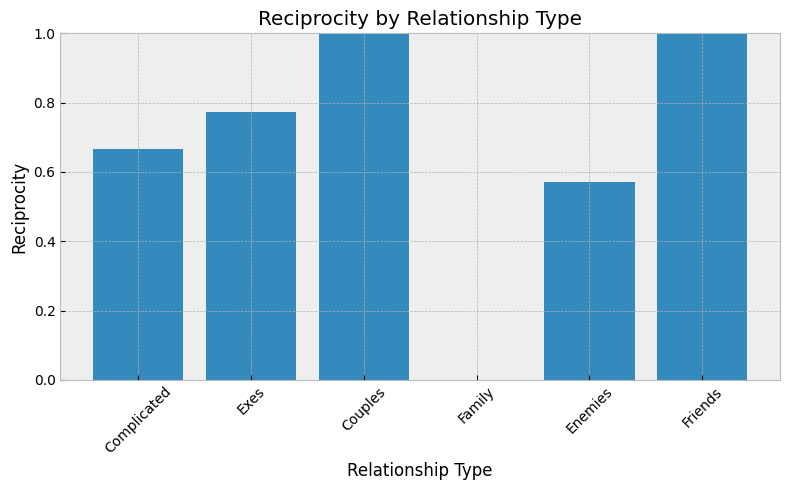

In [104]:
# --- Build directed subgraph for each relationship type ---
reciprocity_per_relation = {}

for u, v, data in G.edges(data=True):
    rel = data["relationship_type"]
    reciprocity_per_relation.setdefault(rel, nx.DiGraph()).add_edge(u, v)

# --- Extract labels and reciprocity values for plotting ---
labels = []
values = []

for rel, G_rel in reciprocity_per_relation.items():
    reciprocity = nx.reciprocity(G_rel)
    labels.append(rel)
    values.append(reciprocity)

# --- Bar chart of reciprocity per relation ---
plt.figure(figsize=(8, 5))
plt.bar(labels, values)
plt.xlabel("Relationship Type")
plt.ylabel("Reciprocity")
plt.title("Reciprocity by Relationship Type")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [105]:
G_undirected = nx.Graph(G)

# Dizionario: tipo_relazione → lista di archi (senza duplicati)
edges_by_rel = {}

for u, v, data in G.edges(data=True):
    rel = data.get("relationship_type", "unknown")
    edges_by_rel.setdefault(rel, set())
    edges_by_rel[rel].add(tuple(sorted((u, v))))  # rimuove duplicati direzionali

# Calcolo omofilia per ogni tipo di relazione
homophily_gender_per_relation = {}

for rel, edge_set in edges_by_rel.items():
    same = 0
    total = 0

    for u, v in edge_set:
        # Consideriamo solo archi i cui nodi hanno effettivamente il gender
        g1 = G_undirected.nodes[u].get("gender")
        g2 = G_undirected.nodes[v].get("gender")

        if g1 is not None and g2 is not None:
            total += 1
            if g1 == g2:
                same += 1

    if total == 0:
        homophily_gender_per_relation[rel] = None
    else:
        homophily_gender_per_relation[rel] = same / total

# Stampa risultati
for rel, h in homophily_gender_per_relation.items():
    print(f"{rel}: {h}")

Complicated: 0.16666666666666666
Exes: 0.10526315789473684
Couples: 0.0
Family: 0.5
Enemies: 0.8
Friends: 0.0


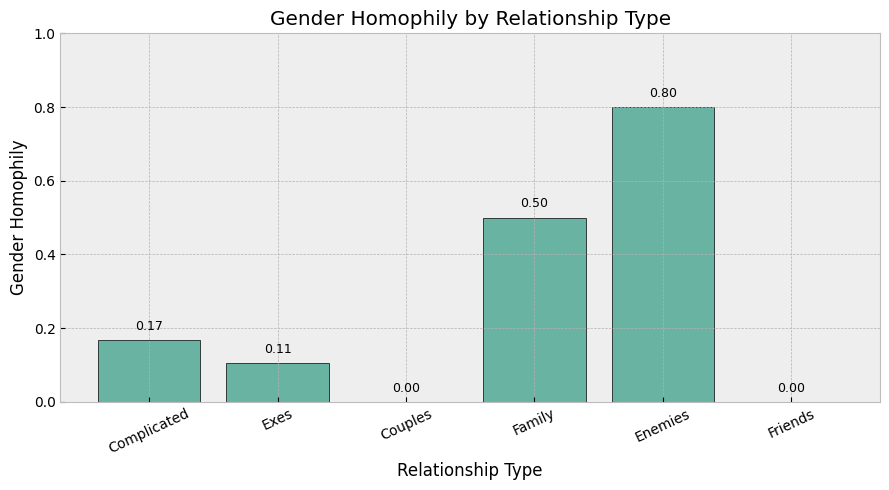

In [106]:
labels = list(homophily_gender_per_relation.keys())
values = [v if v is not None else 0 for v in homophily_gender_per_relation.values()]

# New style: soft grid, minimalistic
plt.figure(figsize=(9, 5))
plt.style.use('bmh')  # different style

bars = plt.bar(labels, values, color="#69b3a2", edgecolor="black")  # softer palette

# Labels
plt.xlabel("Relationship Type")
plt.ylabel("Gender Homophily")
plt.title("Gender Homophily by Relationship Type")
plt.ylim(0, 1)

plt.xticks(rotation=25)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.02,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [ ]:
import os
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import json

# Input/output folders
data_dir = Path("data")
output_dir = Path("results")
output_dir.mkdir(exist_ok=True)

# Load graph depending on file type
def load_graph(path: Path):
    ext = path.suffix.lower()

    if ext == ".gml":
        return nx.read_gml(path)

    if ext in {".graphml", ".graphmlz"}:
        return nx.read_graphml(path)

    if ext in {".edgelist", ".txt"}:
        return nx.read_edgelist(path)

    if ext == ".csv":
        df = pd.read_csv(path)
        if len(df.columns) >= 2:
            return nx.from_pandas_edgelist(df, df.columns[0], df.columns[1])
        else:
            raise ValueError(f"CSV {path} must contain at least 2 columns.")

    # Fallback: try adjacency list
    try:
        return nx.read_adjlist(path)
    except Exception as e:
        raise ValueError(f"Unrecognized file format for {path}: {e}")


# Compute distance-based metrics
def analyze_graph(G, name):
    res = {"name": name}

    # Basic info
    res['n_nodes'] = G.number_of_nodes()
    res['n_edges'] = G.number_of_edges()
    res['directed'] = G.is_directed()

    # Select largest connected component
    if G.is_directed():
        try:
            comp_sets = list(nx.strongly_connected_components(G))
            largest = max(comp_sets, key=len)
            H = G.subgraph(largest).copy().to_undirected()
            res['used_component'] = 'largest_strongly_connected'
        except Exception:
            comp_sets = list(nx.weakly_connected_components(G))
            largest = max(comp_sets, key=len)
            H = G.subgraph(largest).copy().to_undirected()
            res['used_component'] = 'largest_weakly_connected'
    else:
        comp_sets = list(nx.connected_components(G))
        largest = max(comp_sets, key=len) if comp_sets else set()
        H = G.subgraph(largest).copy()
        res['used_component'] = 'largest_connected'

    res['component_nodes'] = H.number_of_nodes()
    res['component_edges'] = H.number_of_edges()

    # Too small to compute distances
    if H.number_of_nodes() <= 1:
        res['diameter'] = None
        res['average_path_length'] = None
        res['notes'] = "component too small"
        return res

    # Diameter
    try:
        res['diameter'] = nx.diameter(H)
    except Exception as e:
        res['diameter'] = None
        res['diameter_error'] = str(e)

    # Average path length
    try:
        res['average_path_length'] = nx.average_shortest_path_length(H)
    except Exception as e:
        res['average_path_length'] = None
        res['apl_error'] = str(e)

    # Path length distribution (full or sampled)
    try:
        n = H.number_of_nodes()
        max_pairs = 200000  # threshold for full computation

        if n * (n - 1) / 2 <= max_pairs:
            # Compute all-pairs shortest paths
            lengths = dict(nx.all_pairs_shortest_path_length(H))
            dists = []
            for u in lengths:
                dists.extend(lengths[u].values())
            res['path_length_hist'] = pd.Series(dists).value_counts().sort_index().to_dict()

        else:
            # Sampling for large graphs
            import random
            nodes = list(H.nodes())
            pairs = set()
            sampled = []
            samples = 20000

            for _ in range(samples):
                a, b = random.sample(nodes, 2)
                if (a, b) not in pairs:
                    pairs.add((a, b))
                    try:
                        l = nx.shortest_path_length(H, a, b)
                        sampled.append(l)
                    except nx.NetworkXNoPath:
                        pass

            res['path_length_hist_sampled'] = pd.Series(sampled).value_counts().sort_index().to_dict()

    except Exception as e:
        res['path_length_hist_error'] = str(e)

    return res


# Process all graph files
all_results = []

for fpath in sorted(data_dir.rglob("*.*")):

    # Skip irrelevant file types
    if fpath.suffix.lower() in {'.py', '.md', '.gitignore'}:
        continue

    if fpath.is_file():
        name = fpath.stem

        try:
            G = load_graph(fpath)
        except Exception as e:
            print(f"[WARN] Cannot load {fpath.name}: {e}")
            continue

        print(f"Analyzing {fpath.name}: nodes={G.number_of_nodes()} edges={G.number_of_edges()} directed={G.is_directed()}")
        r = analyze_graph(G, name)
        all_results.append(r)


# Save results
df_res = pd.DataFrame(all_results)
df_res.to_csv(output_dir / "graph_distance_measures.csv", index=False)

with open(output_dir / "graph_distance_measures.json", "w") as fh:
    json.dump(all_results, fh, indent=2)

print("Results saved in", output_dir)


# Save plots for each graph
for r in all_results:

    base = output_dir / r['name']

    # Path length histogram
    hist = r.get('path_length_hist') or r.get('path_length_hist_sampled')
    if hist:
        keys = sorted(int(k) for k in hist.keys())
        vals = [hist[str(k)] if isinstance(list(hist.keys())[0], str) else hist[k] for k in keys]

        plt.figure()
        plt.bar(keys, vals)
        plt.xlabel("Shortest path length")
        plt.ylabel("Count")
        plt.title(f"Path length distribution: {r['name']}")
        plt.tight_layout()
        plt.savefig(base.with_suffix(".path_hist.png"))
        plt.close()

    # Degree distribution (if GML exists)
    try:
        Gpath = data_dir / (r['name'] + ".gml")

        if Gpath.exists():
            Gtmp = load_graph(Gpath)
            degs = [d for n, d in Gtmp.degree()]

            plt.figure()
            plt.hist(degs, bins=30)
            plt.xlabel("Degree")
            plt.ylabel("Count")
            plt.title(f"Degree distribution: {r['name']}")
            plt.tight_layout()
            plt.savefig(base.with_suffix(".degree_hist.png"))
            plt.close()
    except Exception:
        pass


# Display summary
display(df_res[['name', 'n_nodes', 'n_edges', 'component_nodes', 'component_edges', 'diameter', 'average_path_length']])


[WARN] Cannot load .gitignore: Unrecognized file format for data/.gitignore: pop from empty list
Analyzing Penguins of Kyoto - Complicated Metadata.csv: nodes=7 edges=5 directed=False
Analyzing Penguins of Kyoto - Complicated.csv: nodes=60 edges=59 directed=False
Analyzing Penguins of Kyoto - Couples Metadata.csv: nodes=20 edges=10 directed=False
Analyzing Penguins of Kyoto - Couples.csv: nodes=61 edges=59 directed=False
Analyzing Penguins of Kyoto - Enemies Metadata.csv: nodes=7 edges=5 directed=False
Analyzing Penguins of Kyoto - Enemies.csv: nodes=60 edges=59 directed=False
Analyzing Penguins of Kyoto - Exes Metadata.csv: nodes=15 edges=11 directed=False
Analyzing Penguins of Kyoto - Exes.csv: nodes=60 edges=59 directed=False
Analyzing Penguins of Kyoto - Family.csv: nodes=61 edges=59 directed=False
Analyzing Penguins of Kyoto - Friends Metadata.csv: nodes=2 edges=1 directed=False
Analyzing Penguins of Kyoto - Friends.csv: nodes=60 edges=59 directed=False
Analyzing Penguins of Kyoto

,name,n_nodes,n_edges,component_nodes,component_edges,diameter,average_path_length
0,Penguins of Kyoto - Complicated Metadata,7,5,4,3,3,1.666667
1,Penguins of Kyoto - Complicated,60,59,60,59,2,1.966667
2,Penguins of Kyoto - Couples Metadata,20,10,2,1,1,1.000000
3,Penguins of Kyoto - Couples,61,59,59,58,2,1.966102
4,Penguins of Kyoto - Enemies Metadata,7,5,5,4,3,1.800000
5,Penguins of Kyoto - Enemies,60,59,60,59,2,1.966667
6,Penguins of Kyoto - Exes Metadata,15,11,8,7,3,1.928571
7,Penguins of Kyoto - Exes,60,59,60,59,2,1.966667
8,Penguins of Kyoto - Family,61,59,57,56,2,1.964912
9,Penguins of Kyoto - Friends Metadata,2,1,2,1,1,1.000000


→ Loading Complicated network from data/gexf/Penguin_Complicated.gexf
→ Loading Couples network from data/gexf/Penguin_Couples.gexf
→ Loading Enemies network from data/gexf/Penguin_Enemies.gexf
→ Loading Exes network from data/gexf/Penguin_Exes.gexf
→ Loading Family network from data/gexf/Penguin_Family.gexf
→ Loading Friends network from data/gexf/Penguin_Friends.gexf
MultiGraph combined: nodes=59, edges=139
Weighted simple graph: nodes=59, edges=97

=== TRIADS / TRIANGLES ===
Triangles (count): 22
Global transitivity: 0.21710526315789475

=== CLIQUES ===
Total maximal cliques: 64
Large cliques (>=4): 1
Max k-core: 3

=== COMMUNITY (Louvain) ===
Number of communities: 12
Modularity: 0.7231220576986461


/var/folders/7d/kd7mzjtj0bzd8nk8vk_45rnr0000gn/T/ipykernel_46928/105254007.py:148: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("cool", n_communities)


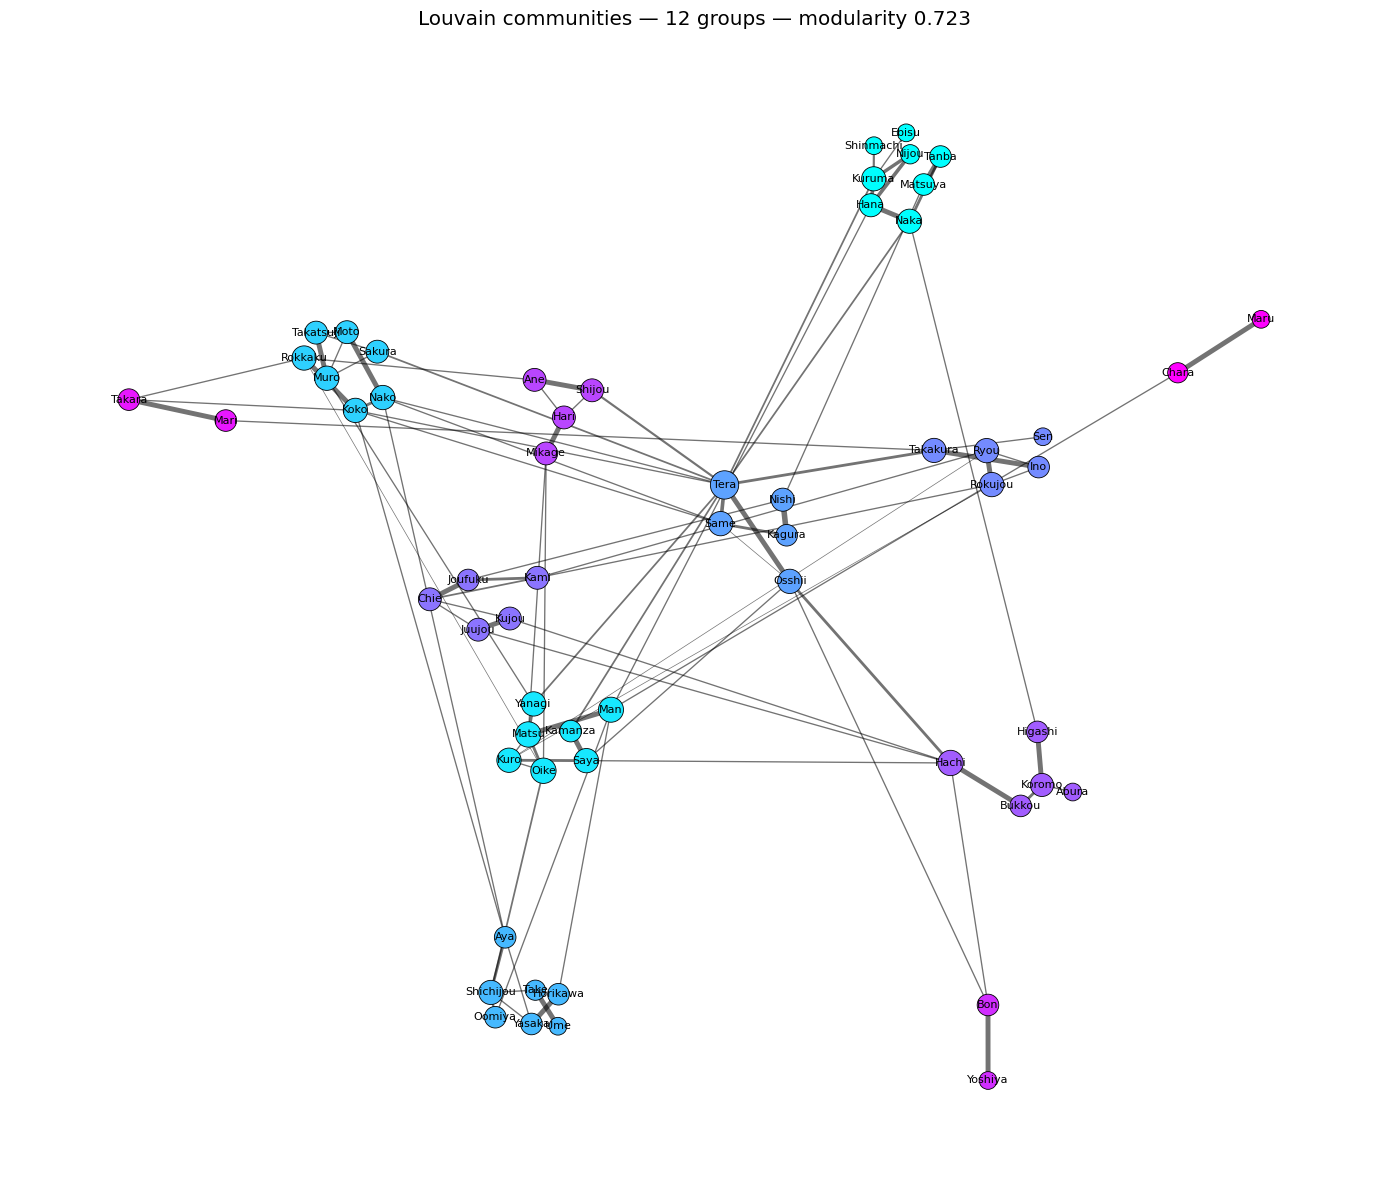

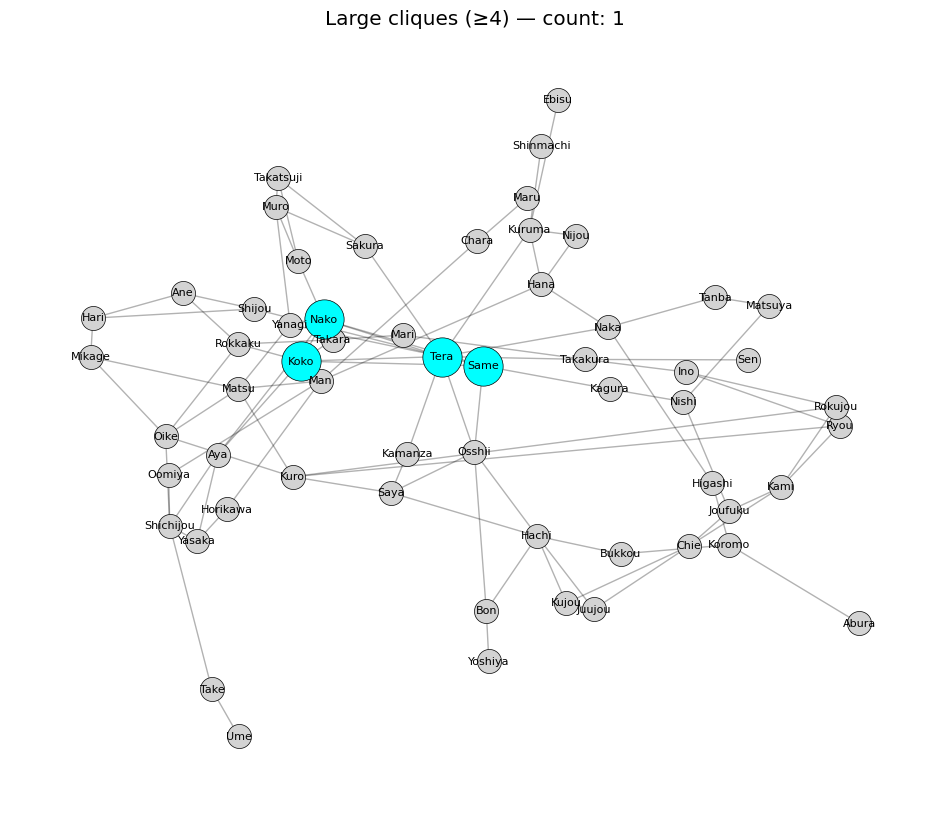


Community summary:
 - community 0: nodes=8, density=0.286, triangles=1
 - community 1: nodes=7, density=0.333, triangles=1
 - community 4: nodes=7, density=0.381, triangles=2
 - community 11: nodes=7, density=0.333, triangles=1
 - community 3: nodes=5, density=0.500, triangles=1
 - community 9: nodes=5, density=0.500, triangles=1
 - community 2: nodes=5, density=0.600, triangles=2
 - community 5: nodes=5, density=0.400, triangles=0
 - community 6: nodes=4, density=0.667, triangles=1
 - community 7: nodes=2, density=1.000, triangles=0
 - community 8: nodes=2, density=1.000, triangles=0
 - community 10: nodes=2, density=1.000, triangles=0

Pipeline completed.


In [108]:
import community.community_louvain as community  # Louvain method
import math

# Load metadata (gender info)
metadata_path = "data/csv/Penguins of Kyoto - Metadata.csv"
meta = pd.read_csv(metadata_path)
meta["Name"] = meta["Name"].astype(str).str.strip()

gender_map = {}
for _, row in meta.iterrows():
    name = str(row["Name"]).strip()
    g = str(row["Gender"]).lower().strip()
    if g.startswith("m"):
        gender_map[name] = "skyblue"     # male
    elif g.startswith("f"):
        gender_map[name] = "lightpink"   # female
    else:
        gender_map[name] = "gray"        # unknown


# Load multilayer GEXF networks
DATA_DIR = "data/gexf"
gexf_files = [
    "Penguin_Complicated.gexf",
    "Penguin_Couples.gexf",
    "Penguin_Enemies.gexf",
    "Penguin_Exes.gexf",
    "Penguin_Family.gexf",
    "Penguin_Friends.gexf",
]

color_map = {
    "Couples": "red",
    "Exes": "blue",
    "Complicated": "purple",
    "Family": "orange",
    "Friends": "green",
    "Enemies": "gray"
}

G = nx.MultiGraph()

# Merge all GEXF files
for file in gexf_files:
    path = os.path.join(DATA_DIR, file)
    relation = file.split("_")[1].split(".")[0]

    print(f"→ Loading {relation} network from {path}")
    Gi = nx.read_gexf(path)

    # Add edges with relationship attribute
    for u, v in Gi.edges():
        G.add_edge(u.strip(), v.strip(), relationship_type=relation)

print(f"MultiGraph combined: nodes={G.number_of_nodes()}, edges={G.number_of_edges()}")


# Convert to weighted simple graph
RELATION_WEIGHTS = {
    "Friends": 1.0,
    "Couples": 1.0,
    "Complicated": 0.7,
    "Exes": 0.5,
    "Enemies": 0.0,
    "Family": 0.3
}

G_simple = nx.Graph()

# Sum weights when multiple relations exist
for u, v, data in G.edges(data=True):
    rel = data["relationship_type"]
    w = RELATION_WEIGHTS.get(rel, 0)

    if G_simple.has_edge(u, v):
        G_simple[u][v]["weight"] += w
    else:
        G_simple.add_edge(u, v, weight=w)

print(f"Weighted simple graph: nodes={G_simple.number_of_nodes()}, edges={G_simple.number_of_edges()}")


# Triangles / Triads
triangles_dict = nx.triangles(G_simple)
triangles_count = sum(triangles_dict.values()) // 3

print("\n=== TRIADS / TRIANGLES ===")
print("Triangles (count):", triangles_count)
print("Global transitivity:", nx.transitivity(G_simple))


# Cliques
cliques = list(nx.find_cliques(G_simple))
large_cliques = [c for c in cliques if len(c) >= 4]

print("\n=== CLIQUES ===")
print("Total maximal cliques:", len(cliques))
print("Large cliques (>=4):", len(large_cliques))

# Count clique participation per node
clique_participation = {n: 0 for n in G_simple.nodes()}
for c in cliques:
    for n in c:
        clique_participation[n] += 1


# K-core
core_numbers = nx.core_number(G_simple)
print("Max k-core:", max(core_numbers.values()))


# Louvain community detection
print("\n=== COMMUNITY (Louvain) ===")
partition = community.best_partition(G_simple, weight="weight")
n_communities = len(set(partition.values()))

modularity = community.modularity(partition, G_simple, weight="weight")
print("Number of communities:", n_communities)
print("Modularity:", modularity)

# Group nodes by community
from collections import defaultdict
communities = defaultdict(list)
for node, com in partition.items():
    communities[com].append(node)

# Community plot (enhanced layout)
plt.figure(figsize=(14, 12))

# Create graph with strong intra-community attraction
H = G_simple.copy()
INTRA_FORCE = 5.0

for com, nodes in communities.items():
    for i in range(len(nodes)):
        for j in range(i + 1, len(nodes)):
            u, v = nodes[i], nodes[j]
            if not H.has_edge(u, v):
                H.add_edge(u, v, weight=INTRA_FORCE)
            else:
                H[u][v]["weight"] += INTRA_FORCE

# Layout influenced by community structure
pos = nx.spring_layout(H, seed=42, k=0.35, weight="weight")

# Assign colors to communities
sorted_coms = sorted(communities.keys(), key=lambda c: -len(communities[c]))
cmap = plt.cm.get_cmap("cool", n_communities)
community_color = {com: cmap(i) for i, com in enumerate(sorted_coms)}
node_colors = [community_color[partition[n]] for n in G_simple.nodes()]

# Node size: based on clique participation + core number
node_sizes = [
    50 + 120 * math.log(1 + clique_participation[n]) + 30 * core_numbers[n]
    for n in G_simple.nodes()
]

# Edge width proportional to weight
edge_weights = [G_simple[u][v]["weight"] for u, v in G_simple.edges()]
ew_max = max(edge_weights)
edge_widths = [0.5 + 3.5 * (w / ew_max) for w in edge_weights]

# Draw graph
nx.draw_networkx_edges(G_simple, pos, alpha=0.55, width=edge_widths)
nx.draw_networkx_nodes(
    G_simple, pos,
    node_size=node_sizes,
    node_color=node_colors,
    edgecolors="black", linewidths=0.6
)
nx.draw_networkx_labels(G_simple, pos, font_size=8)

plt.title(f"Louvain communities — {n_communities} groups — modularity {modularity:.3f}")
plt.axis("off")
plt.tight_layout()
plt.show()

# Clique plot
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G_simple, seed=42)

nx.draw_networkx_nodes(G_simple, pos, node_color="lightgray", node_size=300, edgecolors="black")
nx.draw_networkx_edges(G_simple, pos, alpha=0.3)
nx.draw_networkx_labels(G_simple, pos, font_size=8)

# Highlight large cliques
for clique in large_cliques:
    nx.draw_networkx_nodes(
        G_simple, pos,
        nodelist=clique,
        node_color="cyan",
        node_size=800,
        edgecolors="black"
    )

plt.title(f"Large cliques (≥4) — count: {len(large_cliques)}")
plt.axis("off")
plt.show()

# Community summary (table output)
print("\nCommunity summary:")
for com, nodes in sorted(communities.items(), key=lambda x: -len(x[1])):
    subg = G_simple.subgraph(nodes)
    dens = nx.density(subg)
    tri = sum(nx.triangles(subg).values()) // 3
    print(f" - community {com}: nodes={len(nodes)}, density={dens:.3f}, triangles={tri}")

print("\nPipeline completed.")
